## Vanishing Gradients

#### In this notebook, we will demonstrate the difference between using sigmoid and ReLU nonlinearities in a simple neural network with two hidden layers.

This notebook is built off of a minimal net demo done by Andrej Karpathy for CS 231n, which you can check out here: http://cs231n.github.io/neural-networks-case-study/

Source: https://cs224d.stanford.edu/notebooks/vanishing_grad_example.html


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


(-1.0, 1.0)

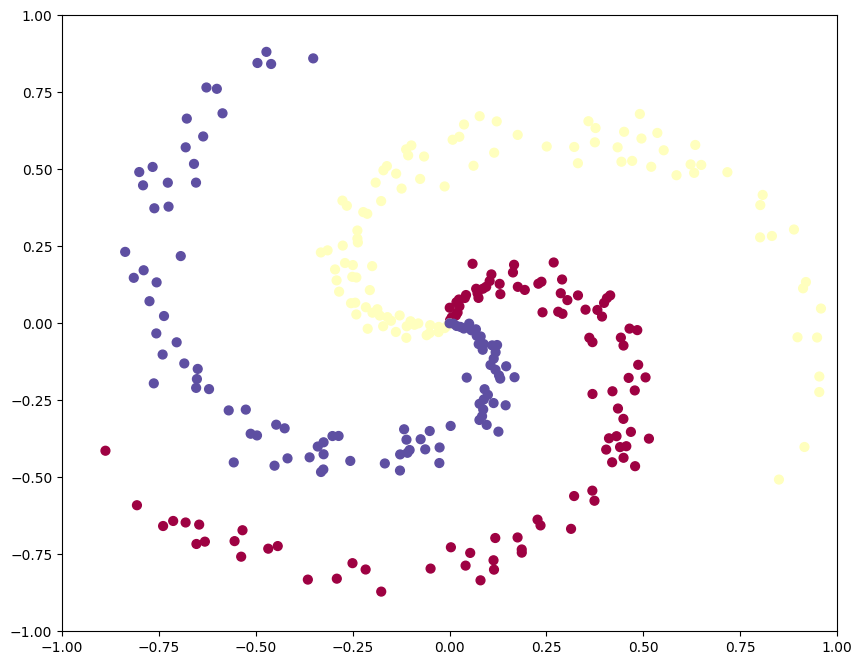

In [2]:
# Generate random data -- not linearly separable 
np.random.seed(0)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D))
num_train_examples = X.shape[0]
y = np.zeros(N*K, dtype='uint8')
for j in range(K):
    ix = range(N*j,N*(j+1))
    r = np.linspace(0.0,1,N) # radius
    t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j
fig = plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim([-1,1])
plt.ylim([-1,1])


The sigmoid function "squashes" inputs to lie between 0 and 1. Unfortunately, this means that for inputs with sigmoid output close to 0 or 1, the gradient with respect to those inputs are close to zero. This leads to the phenomenon of vanishing gradients, where gradients drop close to zero, and the net does not learn well.

On the other hand, the relu function (max(0, x)) does not saturate with input size. Plot these functions to gain intuition.


In [3]:
def sigmoid(x):
    x = 1/(1+np.exp(-x))
    return x

def sigmoid_grad(x):
    return (x)*(1-x)

def relu(x):
    return np.maximum(0,x)


Let's try and see now how the two kinds of nonlinearities change deep neural net training in practice. Below, we build a very simple neural net with three layers (two hidden layers), for which you can swap out ReLU/ sigmoid nonlinearities.


In [5]:
# Function to train a three layer neural net with either RELU or sigmoid nonlinearity via vanilla grad descent

def three_layer_net(NONLINEARITY, X, y, model, step_size, reg):
    # Parameter initialization
    h = model['h']
    h2 = model['h2']
    W1 = model['W1']
    W2 = model['W2']
    W3 = model['W3']
    b1 = model['b1']
    b2 = model['b2']
    b3 = model['b3']
    
    # Gradient descent loop
    num_examples = X.shape[0]
    plot_array_1 = []
    plot_array_2 = []
    
    for i in range(50000):
        # FORWARD PROP
        if NONLINEARITY == 'RELU':
            hidden_layer = relu(np.dot(X, W1) + b1)
            hidden_layer2 = relu(np.dot(hidden_layer, W2) + b2)
            scores = np.dot(hidden_layer2, W3) + b3
        elif NONLINEARITY == 'SIGM':
            hidden_layer = sigmoid(np.dot(X, W1) + b1)
            hidden_layer2 = sigmoid(np.dot(hidden_layer, W2) + b2)
            scores = np.dot(hidden_layer2, W3) + b3

        exp_scores = np.exp(scores)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True) # [N x K]

        # Compute the loss: average cross-entropy loss and regularization
        corect_logprobs = -np.log(probs[range(num_examples), y])
        data_loss = np.sum(corect_logprobs) / num_examples
        reg_loss = 0.5*reg*np.sum(W1*W1) + 0.5*reg*np.sum(W2*W2) + 0.5*reg*np.sum(W3*W3)
        loss = data_loss + reg_loss
        
        if i % 1000 == 0:
            print("iteration %d: loss %f" % (i, loss))

        # Compute the gradient on scores
        dscores = probs
        dscores[range(num_examples), y] -= 1
        dscores /= num_examples

        # BACKPROP HERE
        dW3 = (hidden_layer2.T).dot(dscores)
        db3 = np.sum(dscores, axis=0, keepdims=True)

        if NONLINEARITY == 'RELU':
            # Backprop ReLU nonlinearity here
            dhidden2 = np.dot(dscores, W3.T)
            dhidden2[hidden_layer2 <= 0] = 0
            dW2 = np.dot(hidden_layer.T, dhidden2)
            plot_array_2.append(np.sum(np.abs(dW2)) / np.sum(np.abs(dW2.shape)))
            db2 = np.sum(dhidden2, axis=0)
            dhidden = np.dot(dhidden2, W2.T)
            dhidden[hidden_layer <= 0] = 0
            
        elif NONLINEARITY == 'SIGM':
            # Backprop sigmoid nonlinearity here
            dhidden2 = dscores.dot(W3.T) * sigmoid_grad(hidden_layer2)
            dW2 = (hidden_layer.T).dot(dhidden2)
            plot_array_2.append(np.sum(np.abs(dW2)) / np.sum(np.abs(dW2.shape)))
            db2 = np.sum(dhidden2, axis=0)
            dhidden = dhidden2.dot(W2.T) * sigmoid_grad(hidden_layer)

        dW1 = np.dot(X.T, dhidden)
        plot_array_1.append(np.sum(np.abs(dW1)) / np.sum(np.abs(dW1.shape)))
        db1 = np.sum(dhidden, axis=0)

        # Add regularization
        dW3 += reg * W3
        dW2 += reg * W2
        dW1 += reg * W1
        
        # Update
        W1 += -step_size * dW1
        b1 += -step_size * db1
        W2 += -step_size * dW2
        b2 += -step_size * db2
        W3 += -step_size * dW3
        b3 += -step_size * db3
        
    # Evaluate training set accuracy
    if NONLINEARITY == 'RELU':
        hidden_layer = relu(np.dot(X, W1) + b1)
        hidden_layer2 = relu(np.dot(hidden_layer, W2) + b2)
    elif NONLINEARITY == 'SIGM':
        hidden_layer = sigmoid(np.dot(X, W1) + b1)
        hidden_layer2 = sigmoid(np.dot(hidden_layer, W2) + b2)
    scores = np.dot(hidden_layer2, W3) + b3
    predicted_class = np.argmax(scores, axis=1)
    print('training accuracy: %.2f' % (np.mean(predicted_class == y)))
    
    return (plot_array_1, plot_array_2, W1, W2, W3, b1, b2, b3)


### Train net with Sigmoid nonlinearity


In [6]:
# Initialize model, train sigmoid net
h = 50 # size of hidden layer 1
h2 = 50 # size of hidden layer 2

model = {}
model['h'] = h
model['h2'] = h2
model['W1'] = 0.1 * np.random.randn(D, h)
model['b1'] = np.zeros((1, h))
model['W2'] = 0.1 * np.random.randn(h, h2)
model['b2'] = np.zeros((1, h2))
model['W3'] = 0.1 * np.random.randn(h2, K)
model['b3'] = np.zeros((1, K))

(sigm_array_1, sigm_array_2, s_W1, s_W2, s_W3, s_b1, s_b2, s_b3) = three_layer_net('SIGM', X, y, model, step_size=1e-1, reg=1e-3)


iteration 0: loss 1.156405
iteration 1000: loss 1.100737
iteration 2000: loss 0.999698
iteration 3000: loss 0.855495
iteration 4000: loss 0.819427
iteration 5000: loss 0.814825
iteration 6000: loss 0.810526
iteration 7000: loss 0.805943
iteration 8000: loss 0.800688
iteration 9000: loss 0.793976
iteration 10000: loss 0.783201
iteration 11000: loss 0.759909
iteration 12000: loss 0.719792
iteration 13000: loss 0.683194
iteration 14000: loss 0.655847
iteration 15000: loss 0.634996
iteration 16000: loss 0.618527
iteration 17000: loss 0.602246
iteration 18000: loss 0.579710
iteration 19000: loss 0.546264
iteration 20000: loss 0.512831
iteration 21000: loss 0.492403
iteration 22000: loss 0.481854
iteration 23000: loss 0.475923
iteration 24000: loss 0.472031
iteration 25000: loss 0.469086
iteration 26000: loss 0.466611
iteration 27000: loss 0.464386
iteration 28000: loss 0.462306
iteration 29000: loss 0.460319
iteration 30000: loss 0.458398
iteration 31000: loss 0.456528
iteration 32000: loss

### Now train net with ReLU nonlinearity


In [8]:
# Re-initialize model, train relu net
model = {}
model['h'] = h
model['h2'] = h2
model['W1'] = 0.1 * np.random.randn(D, h)
model['b1'] = np.zeros((1, h))
model['W2'] = 0.1 * np.random.randn(h, h2)
model['b2'] = np.zeros((1, h2))
model['W3'] = 0.1 * np.random.randn(h2, K)
model['b3'] = np.zeros((1, K))

(relu_array_1, relu_array_2, r_W1, r_W2, r_W3, r_b1, r_b2, r_b3) = three_layer_net('RELU', X, y, model, step_size=1e-1, reg=1e-3)


iteration 0: loss 1.108852
iteration 1000: loss 0.294098
iteration 2000: loss 0.154213
iteration 3000: loss 0.137443
iteration 4000: loss 0.131893
iteration 5000: loss 0.129002
iteration 6000: loss 0.126939
iteration 7000: loss 0.125329
iteration 8000: loss 0.124004
iteration 9000: loss 0.122933
iteration 10000: loss 0.122061
iteration 11000: loss 0.121325
iteration 12000: loss 0.120712
iteration 13000: loss 0.120180
iteration 14000: loss 0.119721
iteration 15000: loss 0.119317
iteration 16000: loss 0.118950
iteration 17000: loss 0.118623
iteration 18000: loss 0.118329
iteration 19000: loss 0.118064
iteration 20000: loss 0.117822
iteration 21000: loss 0.117599
iteration 22000: loss 0.117389
iteration 23000: loss 0.117185
iteration 24000: loss 0.116932
iteration 25000: loss 0.116696
iteration 26000: loss 0.116483
iteration 27000: loss 0.116247
iteration 28000: loss 0.116017
iteration 29000: loss 0.115807
iteration 30000: loss 0.115613
iteration 31000: loss 0.115427
iteration 32000: loss

# The Vanishing Gradient Issue

We can use the sum of the magnitude of gradients for the weights between hidden layers as a cheap heuristic to measure speed of learning (you can also use the magnitude of gradients for each neuron in the hidden layer here). Intuitively, when the magnitude of the gradients of the weight vectors or of each neuron are large, the net is learning faster.

(NOTE: For our net, each hidden layer has the same number of neurons. If you want to play around with this, make sure to adjust the heuristic to account for the number of neurons in the layer).


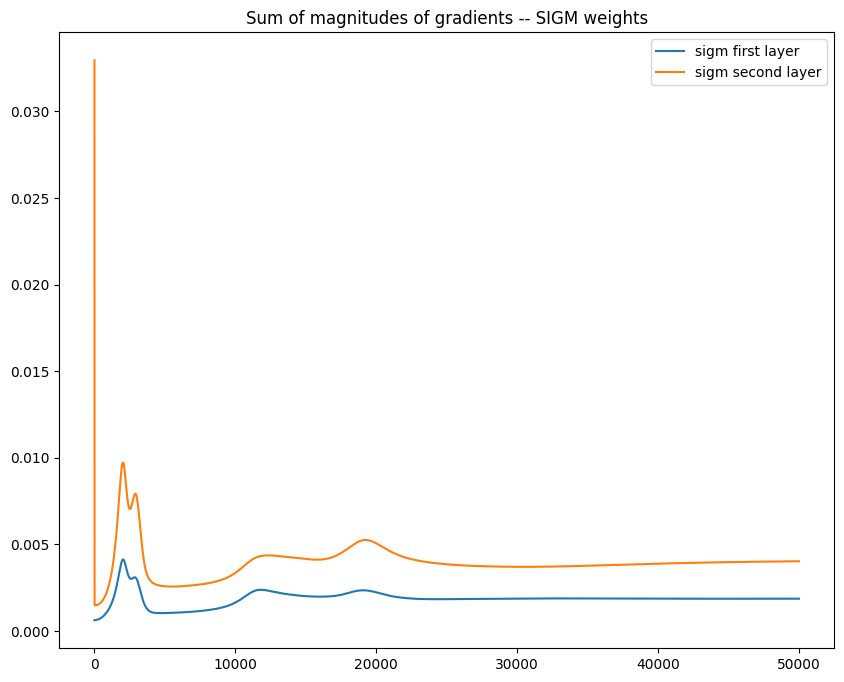

In [9]:
plt.plot(np.array(sigm_array_1))
plt.plot(np.array(sigm_array_2))
plt.title('Sum of magnitudes of gradients -- SIGM weights')
plt.legend(("sigm first layer", "sigm second layer"))


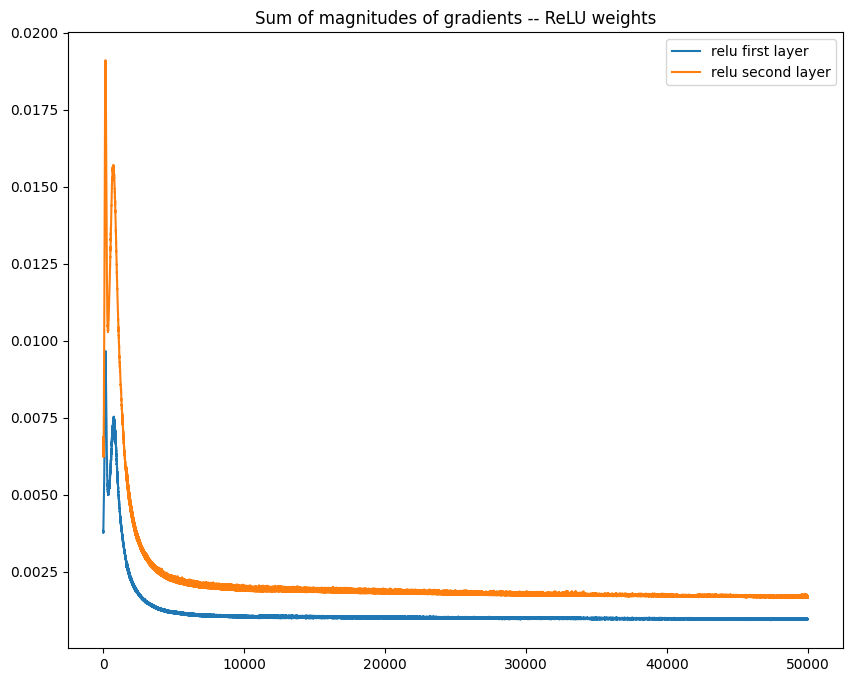

In [10]:
plt.plot(np.array(relu_array_1))
plt.plot(np.array(relu_array_2))
plt.title('Sum of magnitudes of gradients -- ReLU weights')
plt.legend(("relu first layer", "relu second layer"))


#### Feel free to play around with this notebook to gain intuition. Things you might want to try:

* Adding additional layers to the nets and seeing how early layers continue to train slowly for the sigmoid net
* Experiment with hyperparameter tuning for the nets -- changing regularization and gradient descent step size
* Experiment with different nonlinearities -- Leaky ReLU, Maxout. How quickly do different layers learn now?

We can see how well each classifier does in terms of distinguishing the toy data classes. As expected, since the ReLU net trains faster, for a set number of epochs it performs better compared to the sigmoid net.


Text(0.5, 1.0, 'Sigmoid Classifier')

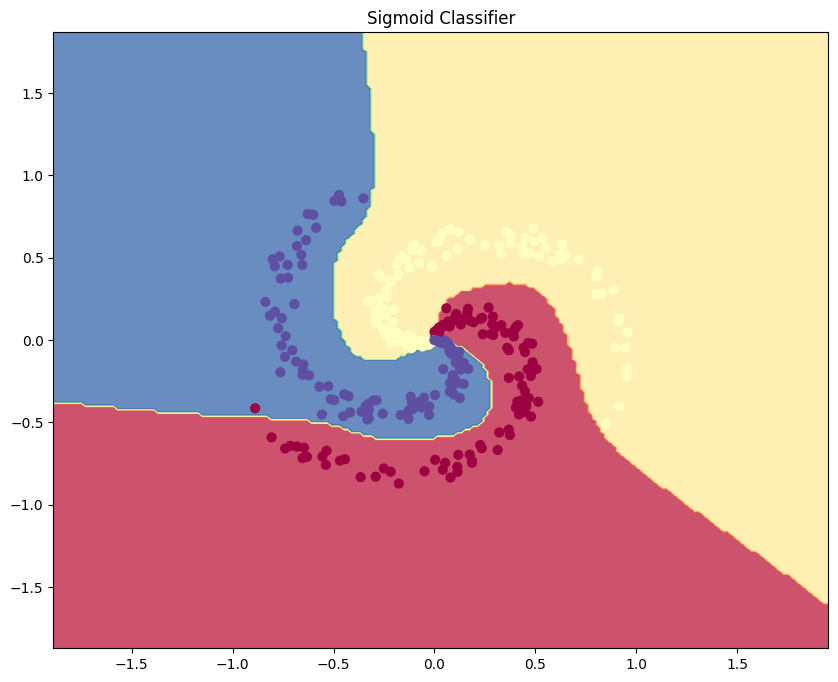

In [11]:
# Plot the classifiers - SIGMOID
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = np.dot(sigmoid(np.dot(sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], s_W1) + s_b1), s_W2) + s_b2), s_W3) + s_b3
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Sigmoid Classifier')


Text(0.5, 1.0, 'ReLU Classifier')

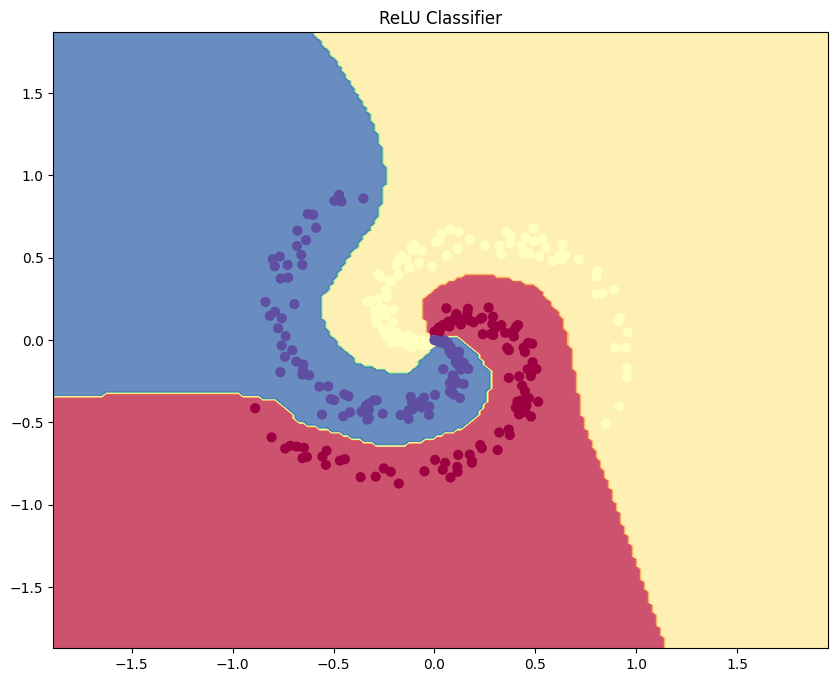

In [12]:
# Plot the classifiers -- RELU
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = np.dot(relu(np.dot(relu(np.dot(np.c_[xx.ravel(), yy.ravel()], r_W1) + r_b1), r_W2) + r_b2), r_W3) + r_b3
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('ReLU Classifier')
